In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_missingness_heatmap(df, id_column, columns_to_check, figsize=(12, 8)):
    """
    Create a heatmap showing missingness patterns and calculate availability percentages.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The input dataframe
    id_column : str
        Column name containing unique identifiers
    columns_to_check : list
        List of column names to check for missingness
    figsize : tuple
        Figure size (width, height), default is (12, 8)
    
    Returns:
    --------
    fig, ax : matplotlib figure and axis objects
    availability_pct : pandas.Series
        Percentage of available values for each column
    """
    # Create a subset with only the relevant columns
    subset_df = df[[id_column] + columns_to_check].copy()
    
    # Set the ID column as index
    subset_df.set_index(id_column, inplace=True)
    
    # Create binary availability matrix (1 = available, 0 = missing)
    availability_matrix = subset_df.notnull().astype(int)
    
    # Calculate column-wise availability percentage
    availability_pct = (availability_matrix.mean() * 100).round(2)
    
    # Create the heatmap
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(availability_matrix, 
                cmap=['#e74c3c', '#2ecc71'],  # Red for missing (0), Green for available (1)
                cbar_kws={'label': 'Available', 'ticks': [0, 1]},
                vmin=0,
                vmax=1,
                yticklabels=True,
                xticklabels=True,
                ax=ax)
    
    # Set labels and title
    ax.set_xlabel('Columns', fontsize=12)
    ax.set_ylabel('Facilities', fontsize=12)
    ax.set_title('Data Availability Heatmap', fontsize=14, fontweight='bold')
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    
    # Print availability percentages
    print("\nColumn-wise Data Availability (%):")
    print("-" * 40)
    for col, pct in availability_pct.items():
        print(f"{col}: {pct}%")
    
    return fig, ax, availability_pct

# Example usage:
# fig, ax, availability = plot_missingness_heatmap(
#     df=my_dataframe,
#     id_column='user_id',
#     columns_to_check=['age', 'income', 'education', 'location']
# )
# plt.show()

In [25]:
import pandas as pd
import os

path_data = 'C:/Users/skar/Box/saura_self/Proj - Water tool analysis/data/output'
fname = 'survey_effluent.xlsx'
sname = 'Sheet1'

df = pd.read_excel(os.path.join(path_data, fname), sheet_name=sname)
print(df.head())

       CWNS_ID  FACILITY_ID                    FACILITY_NAME   LATITUDE  \
0  17000721001      1113995         Stickney Treatment Plant  41.813900   
1  26000596001      1088610                        GLWA WRRF  42.283200   
2  17000721009      1114001  Calumet Water Reclamation Plant  41.662500   
3  11000001001      1142408                  Blue Plains STP  38.816781   
4  29001023002      1133278                       Lemay WWTP  38.532700   

   LONGITUDE         CITY STATE_CODE                         AUTHORITY_NAME  \
0 -87.770400       Cicero         IL                                 MWRDGC   
1 -83.128500      Detroit         MI              DETROIT BOARD OF WATER CO   
2 -87.610000      Chicago         IL                                 MWRDGC   
3 -77.032755   Washington         DC                D.C. WASA (BLUE PLAINS)   
4 -90.270900  Saint Louis         MO  Metropolitan St. Louis Sewer District   

            COUNTY_NAME DESIGN_FLOW  ... NO3_N_AVG_effluent  \
0          


Column-wise Data Availability (%):
----------------------------------------
DESIGN_FLOW: 59.46%
ACTUAL_FLOW_AVG: 100.0%
BOD5_AVG: 64.86%
CBOD5_AVG: 54.05%
SS_AVG: 40.54%
VSS_AVG: 51.35%
TS_AVG: 16.22%
TSS_AVG: 59.46%
VTS_AVG: 10.81%
TKN_AVG: 59.46%
TN_AVG: 10.81%
NH3_N_AVG: 86.49%
NO3_N_AVG: 27.03%
NO2_N_AVG: 18.92%
NO3_N+NO2_N_AVG: 13.51%
P_TOTAL_AVG: 72.97%
P_SOLID_AVG: 10.81%
Electricity_purchased_from_utility_MJ_per_m3: 91.89%
NATURAL_GAS_PURCHASED_onsite_MJ_per_m3: 100.0%
Biogas_generated_onsite_MJ_per_m3: 89.19%
Electricity_produced_onsite_kWh_per_m3: 81.08%
BOD5_AVG_effluent: 56.76%
CBOD5_AVG_effluent: 2.7%
TSS_AVG_effluent: 56.76%
TN_AVG_effluent: 8.11%
NH3_N_AVG_effluent: 56.76%
NO3_N_AVG_effluent: 8.11%
NO2_N_AVG_effluent: 2.7%
NO3_N+NO2_N_AVG_effluent: 5.41%
P_TOTAL_AVG_effluent: 27.03%


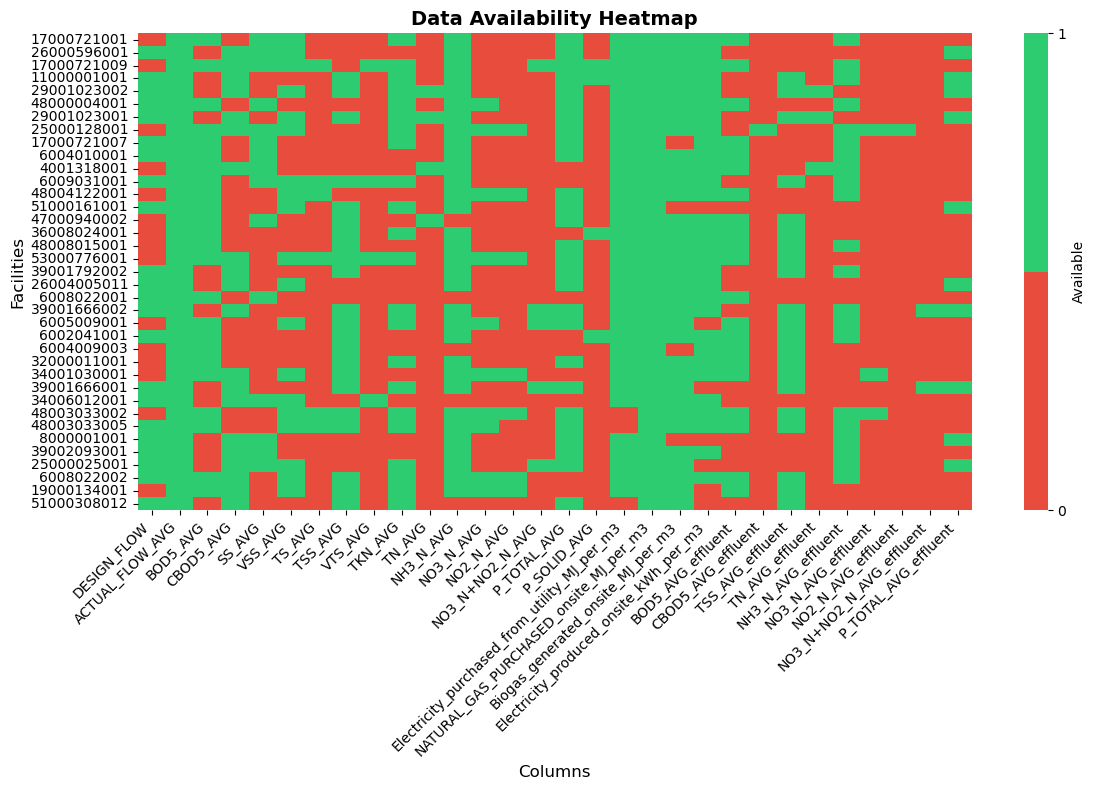

In [27]:
fig, ax, availability = plot_missingness_heatmap(
     df=df,
     id_column='CWNS_ID',
     columns_to_check=[
         'DESIGN_FLOW',
'ACTUAL_FLOW_AVG',
'BOD5_AVG',
'CBOD5_AVG',
'SS_AVG',
'VSS_AVG',
'TS_AVG',
'TSS_AVG',
'VTS_AVG',
'TKN_AVG',
'TN_AVG',
'NH3_N_AVG',
'NO3_N_AVG',
'NO2_N_AVG',
'NO3_N+NO2_N_AVG',
'P_TOTAL_AVG',
'P_SOLID_AVG',
#'Electricity_consumed_onsite_kWh_per_m3',
#'Electricity_purchased_from_utility_kWh_per_m3',
'Electricity_purchased_from_utility_MJ_per_m3',
#'NATURAL_GAS_PURCHASED_onsite_MMBtu_per_m3',
'NATURAL_GAS_PURCHASED_onsite_MJ_per_m3',
#'Biogas_generated_onsite_MMBtu_per_m3',
'Biogas_generated_onsite_MJ_per_m3',
'Electricity_produced_onsite_kWh_per_m3',
#'Total energy purchased_MJ_per_m3_survey'

'BOD5_AVG_effluent',
'CBOD5_AVG_effluent',
#'SS_AVG_effluent',
#'VSS_AVG_effluent',
#'TS_AVG_effluent',
'TSS_AVG_effluent',
#'VTS_AVG_effluent',
#'TKN_AVG_effluent',
'TN_AVG_effluent',
'NH3_N_AVG_effluent',
'NO3_N_AVG_effluent',
'NO2_N_AVG_effluent',
'NO3_N+NO2_N_AVG_effluent',
'P_TOTAL_AVG_effluent',
#'P_SOLID_AVG_effluent',

     ]
)
plt.show()